# Heart Disease Prediction — Exploratory Data Analysis

## UCI Heart Disease Dataset — Cleveland Subset

### Objective

This notebook performs Exploratory Data Analysis (EDA) on the Cleveland subset of the UCI Heart Disease dataset.

The objectives are to:

- Understand the structure and characteristics of the dataset
- Examine numerical and categorical variables
- Analyze missing-value patterns
- Examine the original and binary target distributions
- Identify potential outliers
- Investigate relationships between predictors and heart disease status
- Identify patterns that may influence preprocessing and machine-learning model selection

No machine-learning model is trained in this notebook.

The source dataset file is read without modification. EDA operations are performed on an in-memory dataframe, including construction of the binary target variable.

### 1. Dataset Loading

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_PATH = Path("../data/raw/processed.cleveland.data")

print("Dataset path:", DATA_PATH.resolve())
print("Dataset exists:", DATA_PATH.exists())

columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "num"
]

df = pd.read_csv(
    DATA_PATH,
    names=columns,
    na_values="?"
)

df["target"] = (df["num"] > 0).astype(int)

print("Dataset shape:", df.shape)


Dataset path: C:\Projects\heart-disease-prediction\data\raw\processed.cleveland.data
Dataset exists: True
Dataset shape: (303, 15)


### 2. Descriptive Statistics

In [23]:
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [24]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [25]:
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

df[categorical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
slope,303.0,1.600660,0.616226,1.0,1.0,2.0,2.0,3.0
ca,299.0,0.672241,0.937438,0.0,0.0,0.0,1.0,3.0
thal,301.0,4.734219,1.939706,3.0,3.0,3.0,7.0,7.0


### 3. Numerical Feature Distributions

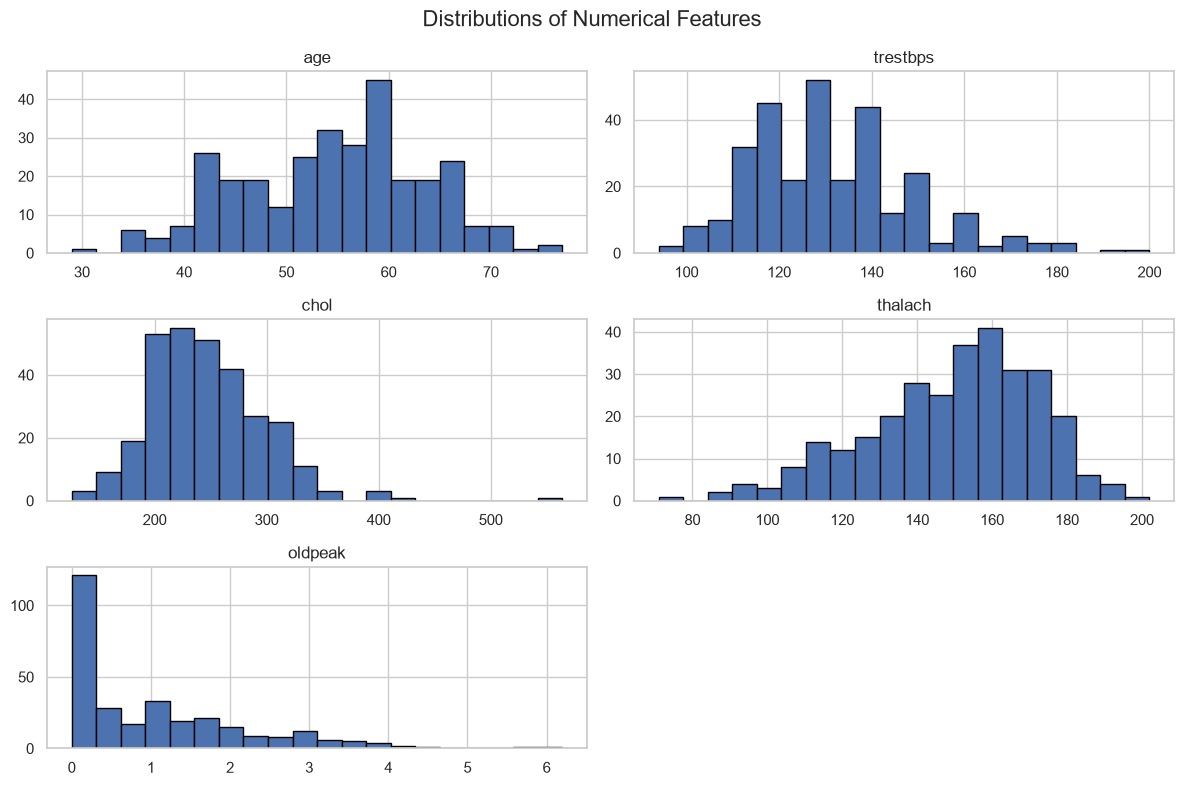

In [26]:
df[numerical_features].hist(
    figsize=(12, 8),
    bins=20,
    edgecolor="black"
)

plt.suptitle(
    "Distributions of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()


### 4. Boxplots and Potential Outliers

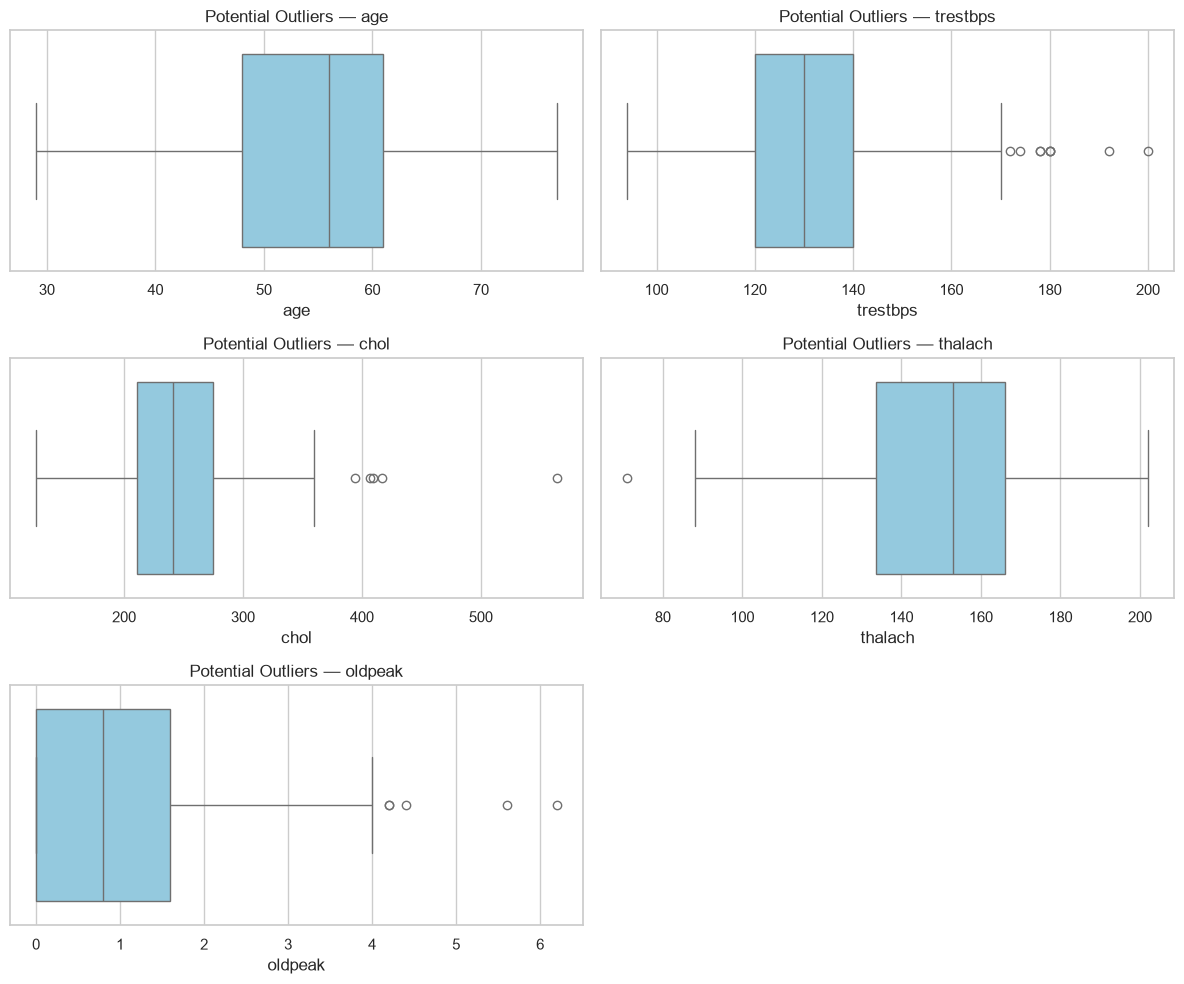

In [27]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12, 10)
)

axes = axes.flatten()

for i, feature in enumerate(numerical_features):

    sns.boxplot(
        data=df,
        x=feature,
        ax=axes[i],
        color="skyblue"
    )

    axes[i].set_title(f"Potential Outliers — {feature}")

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


#### 4.1 Numerical Feature Distribution and Potential Outliers

The numerical features were examined using histograms and boxplots to understand their distributions, spread, and potential unusual observations. The analysis was performed on the Cleveland dataset before imputation, scaling, or encoding.

The `age` variable ranges from 29 to 77 years, with a mean of 54.44 and median of 56 years. The distribution covers a broad adult age range. The difference between the mean and median suggests possible asymmetry, which was examined visually using the histogram.

`trestbps` ranges from 94 to 200, with a mean of 131.69 and median of 130. The upper value of 200 is relatively high compared with the central portion of the distribution and may appear as a potential upper-tail observation in the boxplot. This observation was not considered an error solely because of its statistical extremeness.

`chol` ranges from 126 to 564, with a mean of 246.69 and median of 241. The maximum value of 564 is substantially higher than the third quartile of 275 and may therefore appear as a potential upper outlier. The distribution shows evidence of an extended upper tail. The observation was retained because a statistical outlier is not necessarily an erroneous measurement.

`thalach` ranges from 71 to 202, with a mean of 149.61 and median of 153. The distribution has a relatively broad range, and the difference between the mean and median suggests possible asymmetry. The low-end observations were examined using the boxplot but were not automatically classified as erroneous.

`oldpeak` ranges from 0 to 6.2, with a mean of 1.04 and median of 0.8. The difference between the mean and median, together with the concentration of observations near zero and the higher maximum value, indicates a right-skewed distribution. The value of 6.2 may appear as a potential upper-tail outlier.

Overall, the boxplots identify several statistically unusual observations, particularly for `chol`, `trestbps`, and `oldpeak`. These observations were not removed during EDA. Statistical outlier detection alone does not establish that an observation is incorrect, so no observations were removed solely because they were identified as statistical outliers. The observed distributions are considered when selecting the subsequent preprocessing strategy.


 ### 5. Numerical Features by Target Class
 #### 5.1 Numerical distributions

In [28]:
display(
    df.groupby("target")[numerical_features]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)


age                                 trestbps                        \
       count   mean median   std   min   max    count    mean median    std   
target                                                                        
0        164  52.59   52.0  9.51  29.0  76.0      164  129.25  130.0  16.20   
1        139  56.63   58.0  7.94  35.0  77.0      139  134.57  130.0  18.77   

                      chol                                     thalach  \
          min    max count    mean median    std    min    max   count   
target                                                                   
0        94.0  180.0   164  242.64  234.5  53.46  126.0  564.0     164   
1       100.0  200.0   139  251.47  249.0  49.49  131.0  409.0     139   

                                          oldpeak                               
          mean median    std   min    max   count  mean median   std  min  max  
target                                                                          
0       158.38  161.0  19.20  96.0  202.0     164  0.59    0.2  0.78  0.0  4.2  
1       139.26  142.0  22.59  71.0  195.0     139  1.57    1.4  1.30  0.0  6.2

#### 5.2 Boxplots

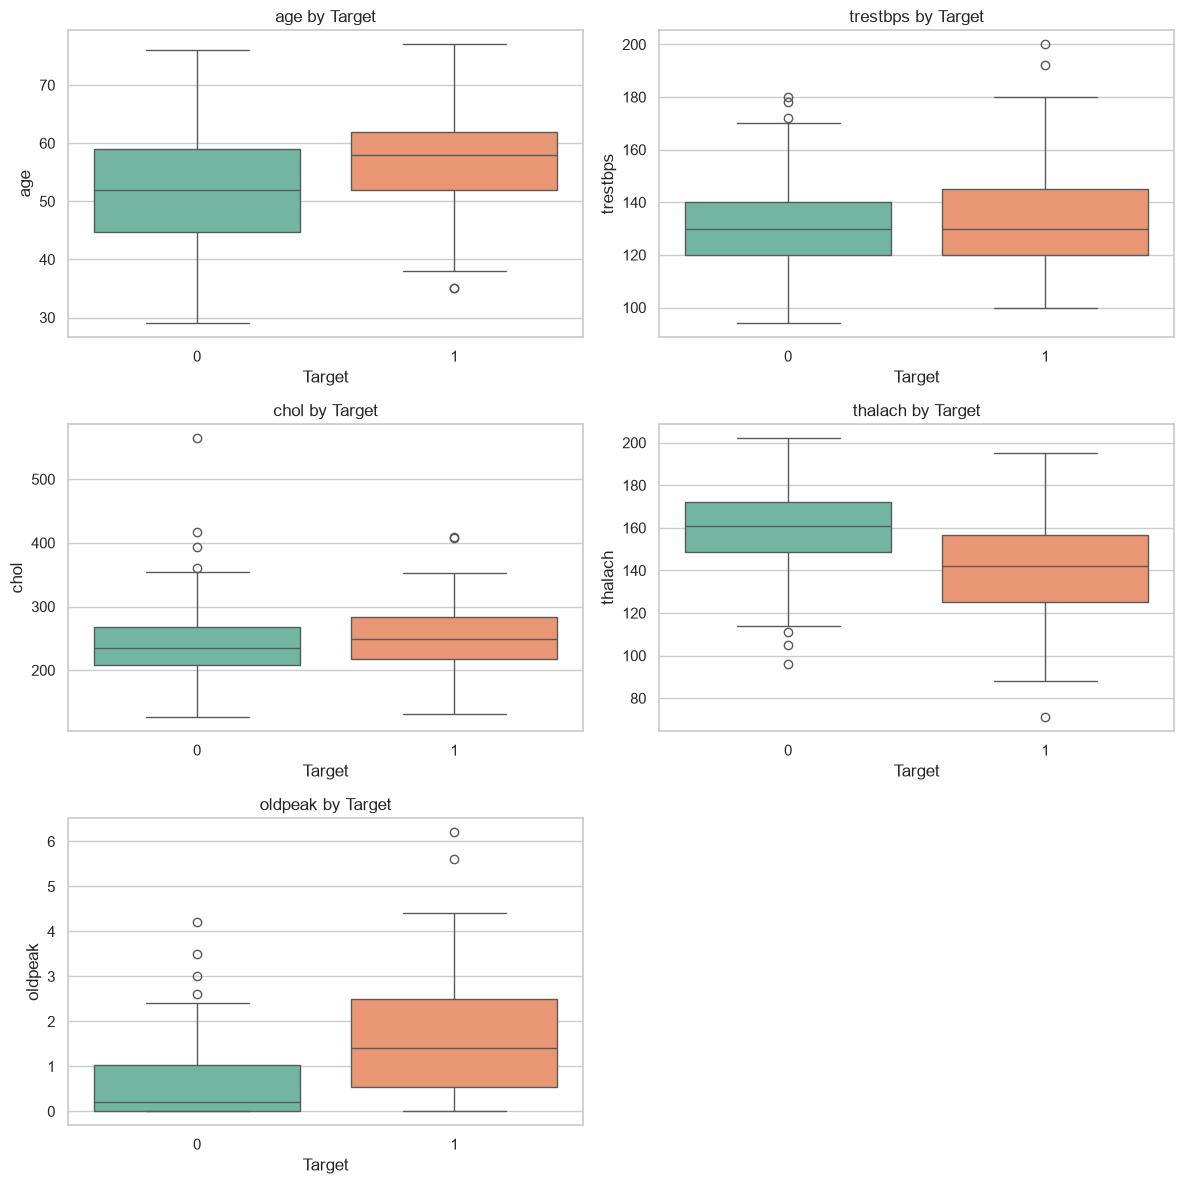

In [29]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12, 12)
)

axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.boxplot(
        data=df,
        x="target",
        y=feature,
        hue="target",
        palette="Set2",
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} by Target")
    axes[i].set_xlabel("Target")
    axes[i].set_ylabel(feature)

for j in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


#### 5.3 Descriptive Observations

The numerical features were compared between the two binary target groups using target-stratified descriptive statistics and boxplots. The observations below describe patterns visible in the dataset and do not represent formal statistical hypothesis-test results.

For `age`, the target = 1 group has a higher median age (58 years) than the target = 0 group (52 years). Although the distributions overlap considerably, the target = 0 group generally contains younger observations.

For `trestbps`, the two target groups have the same median value of 130. The target = 1 group has a higher mean value (134.57) than the target = 0 group (129.25), while both groups show substantial variation.

For `chol`, the target = 1 group has a higher median cholesterol value (249) than the target = 0 group (234.5). The distributions overlap considerably, and the target = 0 group contains the highest observed cholesterol value (564).

For `thalach`, the target = 0 group has a higher median maximum heart rate achieved (161) than the target = 1 group (142). The distributions show noticeable separation, although there is still overlap between the two groups.

For `oldpeak`, the target = 0 group has a substantially lower median value (0.2) than the target = 1 group (1.4). The target = 1 group also shows greater variability in this feature.

Overall, the descriptive analysis suggests that `thalach` and `oldpeak` show more noticeable differences between the target groups, while `age`, `trestbps`, and `chol` show greater overlap. These observations are descriptive and do not by themselves establish statistically significant differences, causal relationships, or clinical significance. Formal statistical testing and effect-size analysis are performed later in the EDA.

### 6. Categorical Features by Target Class
#### 6.1 Category counts

In [30]:
from IPython.display import display

for feature in categorical_features:
    print(f"\n{'=' * 60}")
    print(f"{feature}")
    print(f"{'=' * 60}")

    table = pd.crosstab(
        df[feature],
        df["target"],
        normalize="columns"
    ) * 100

    display(table.round(2))



sex


target,0,1
sex,,
0.0,43.9,17.99
1.0,56.1,82.01



cp


target,0,1
cp,,
1.0,9.76,5.04
2.0,25.00,6.47
3.0,41.46,12.95
4.0,23.78,75.54



fbs


...

target,0,1
slope,,
1.0,64.63,25.90
2.0,29.88,65.47
3.0,5.49,8.63



ca


target,0,1
ca,,
0.0,80.75,33.33
1.0,13.04,31.88
2.0,4.35,22.46
3.0,1.86,12.32



thal


target,0,1
thal,,
3.0,79.14,26.81
6.0,3.68,8.70
7.0,17.18,64.49


#### 6.2 Target-stratified percentages/plots

In [31]:
from IPython.display import display

summary = []

for feature in categorical_features:
    counts = df[feature].value_counts(dropna=False)

    for category, count in counts.items():
        summary.append({
            "Feature": feature,
            "Category": category,
            "Count": count,
            "Percentage": round((count / len(df)) * 100, 2)
        })

summary_df = pd.DataFrame(summary)

display(summary_df)

,Feature,Category,Count,Percentage
0,sex,1.0,206,67.99
1,sex,0.0,97,32.01
2,cp,4.0,144,47.52
3,cp,3.0,86,28.38
4,cp,2.0,50,16.50
5,cp,1.0,23,7.59
6,fbs,0.0,258,85.15
7,fbs,1.0,45,14.85
8,restecg,0.0,151,49.83
9,restecg,2.0,148,48.84


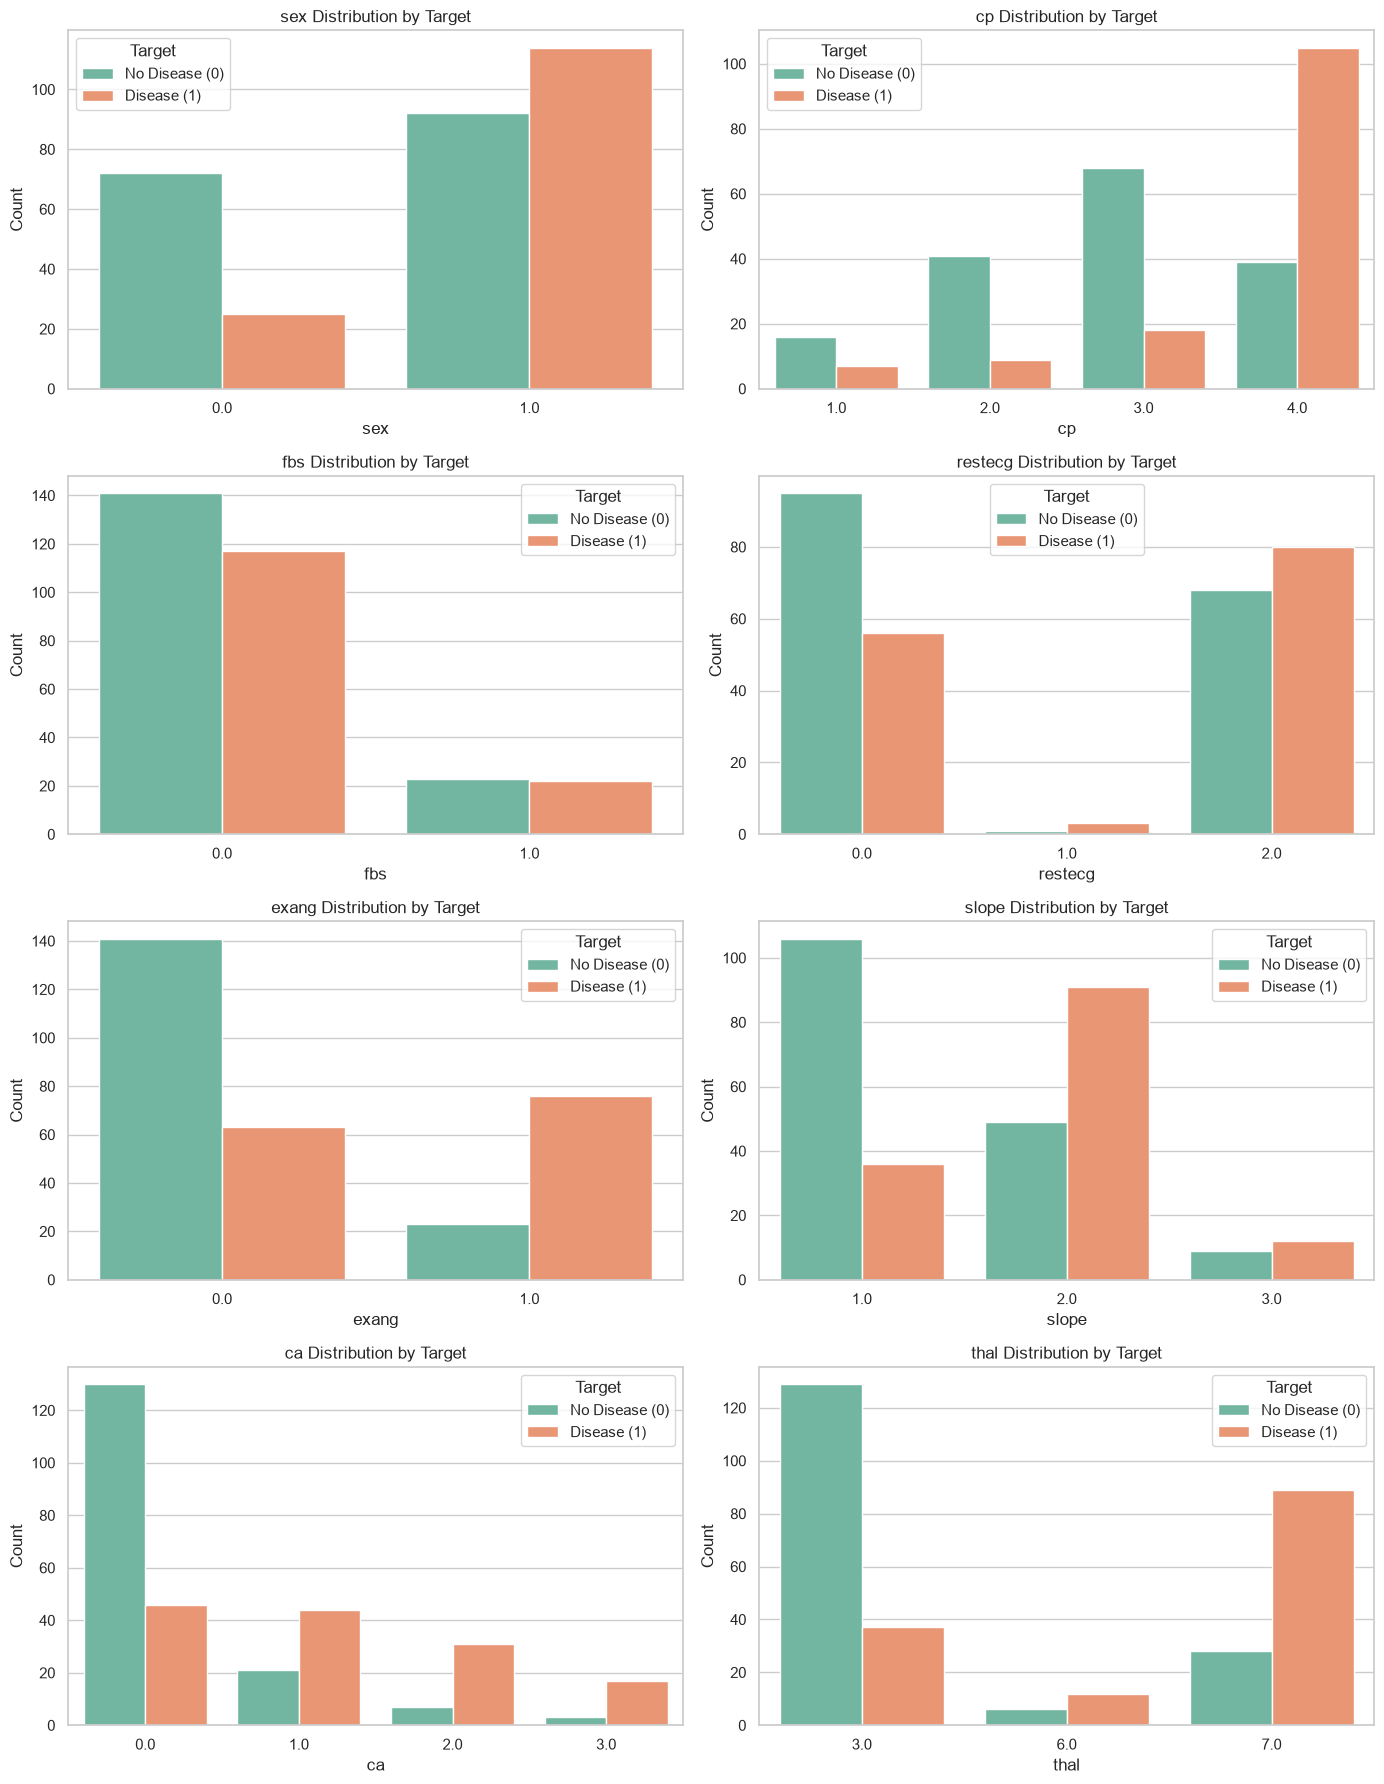

In [32]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(14, 18)
)

axes = axes.flatten()

for i, feature in enumerate(categorical_features):

    sns.countplot(
        data=df,
        x=feature,
        hue="target",
        ax=axes[i],
        palette="Set2"
    )

    axes[i].set_title(f"{feature} Distribution by Target")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")

    axes[i].legend(
        title="Target",
        labels=["No Disease (0)", "Disease (1)"]
    )

plt.tight_layout()
plt.show()

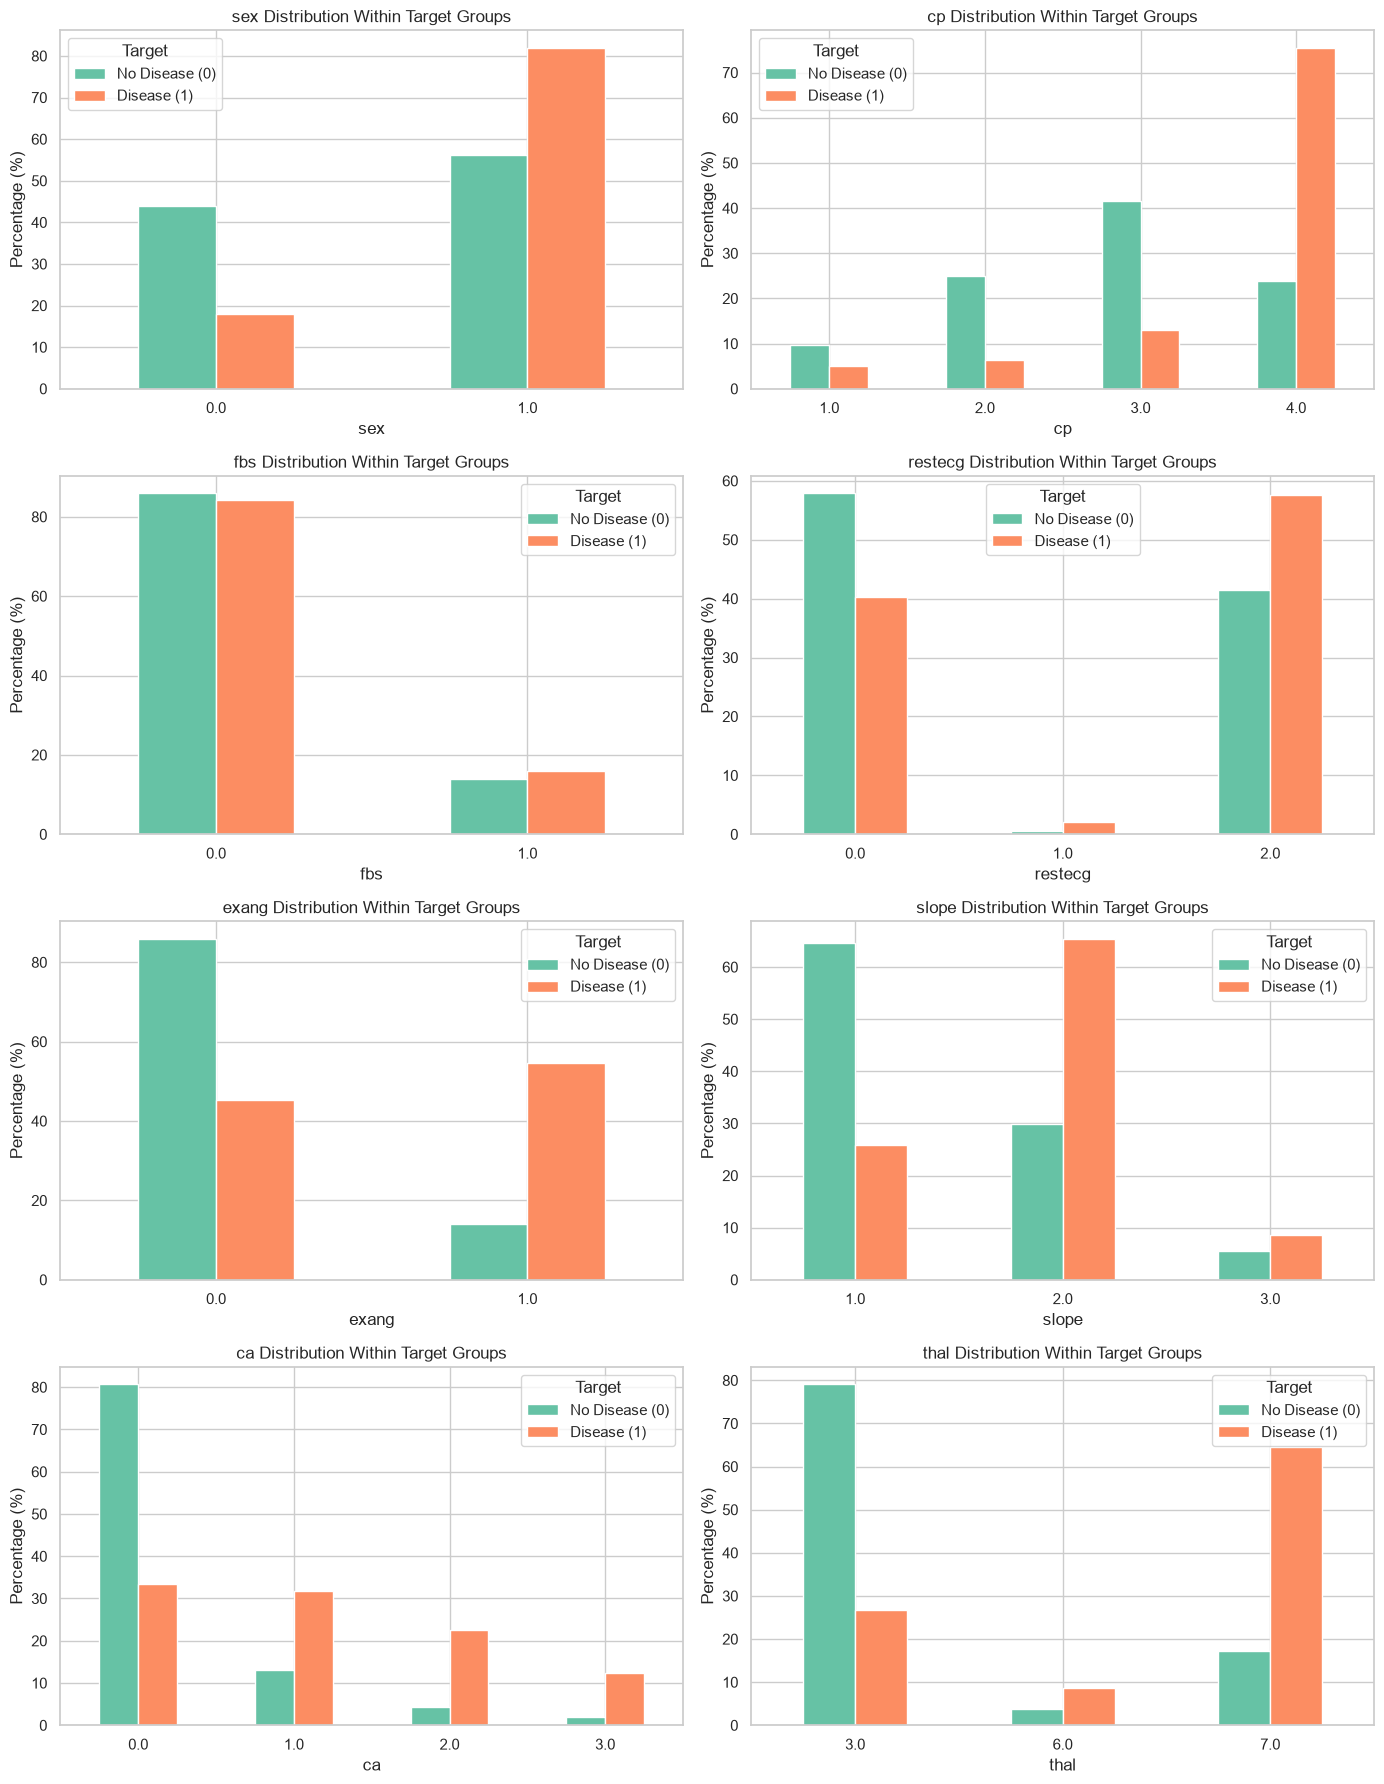

In [33]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(14, 18)
)

axes = axes.flatten()

for i, feature in enumerate(categorical_features):

    percentage_data = (
        pd.crosstab(
            df[feature],
            df["target"],
            normalize="columns"
        ) * 100
    )

    percentage_data.columns = ["No Disease (0)", "Disease (1)"]

    percentage_data.plot(
        kind="bar",
        ax=axes[i],
        color=["#66c2a5", "#fc8d62"]
    )

    axes[i].set_title(f"{feature} Distribution Within Target Groups")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Percentage (%)")
    axes[i].legend(title="Target")

    axes[i].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

#### 6.3 Descriptive Observations

The categorical features were examined using target-stratified counts and percentages to identify differences in category distributions between the two binary target groups. The observations in this section are descriptive and are based on the observed category frequencies and visual comparisons. Formal statistical testing and effect-size analysis are performed later.

For sex, sex = 1 is the more frequent category overall, representing approximately 68.0% of the observations. When examined by target, sex = 0 is more represented in the target = 0 group, whereas sex = 1 is substantially more represented in the target = 1 group.

For cp, category 4 is the most frequent category overall (47.52%), followed by categories 3 (28.38%), 2 (16.50%), and 1 (7.59%). The target-stratified distribution shows that categories 1, 2, and 3 are more concentrated in the target = 0 group, whereas category 4 is substantially more concentrated in the target = 1 group.

For fbs, category 0 accounts for most observations (85.15%), while category 1 represents 14.85%. The proportions are very similar across the two target groups, suggesting little visible difference in the distribution of fbs between target = 0 and target = 1.

For restecg, categories 0 and 2 account for almost all observations, representing 49.83% and 48.84%, respectively. Category 1 is rare, accounting for only 1.32% of the dataset. In the target-stratified distributions, category 0 is more represented in target = 0, whereas category 2 is more represented in target = 1. The small number of observations in category 1 should be considered when interpreting this feature.

For exang, category 0 is more frequent overall (67.33%), while category 1 represents 32.67%. The target-stratified distribution shows that exang = 0 is more concentrated in target = 0, whereas exang = 1 is more concentrated in target = 1.

For slope, categories 1 and 2 have similar overall frequencies, representing 46.86% and 46.20%, respectively, while category 3 is less frequent at 6.93%. In the target-stratified distributions, category 1 is more concentrated in target = 0, whereas category 2 is more concentrated in target = 1. Category 3 occurs relatively infrequently in both groups.

For ca, category 0 is the most frequent category overall (58.09%), followed by categories 1 (21.45%), 2 (12.54%), and 3 (6.60%). The target-stratified distributions show that category 0 is substantially more represented in target = 0, while categories 1, 2, and 3 are more represented in target = 1. There are four missing observations (1.32%), which are retained for separate missing-value analysis.

For thal, category 3 is the most frequent category overall (54.79%), followed by category 7 (38.61%) and category 6 (5.94%). The target-stratified distributions show that category 3 is more concentrated in target = 0, whereas category 7 is substantially more concentrated in target = 1. There are two missing observations (0.66%), which are considered separately in the missing-value analysis.

Overall, the target-stratified visual analysis suggests noticeable differences in the category distributions of several features, particularly cp, exang, ca, and thal. In contrast, fbs shows very similar category distributions between the two target groups. The sparse categories in restecg, as well as the missing observations in ca and thal, should be considered when interpreting the subsequent statistical analysis.

These observations describe patterns present in the Cleveland dataset and do not establish causality, clinical significance, or predictive importance. Formal statistical tests and effect-size measures are evaluated later, followed by machine-learning experiments to assess multivariable predictive performance.

### 7. Statistical Verification

To complement the descriptive and visual EDA, statistical tests were used to examine whether the distributions of predictor variables differed between the two binary target groups.

For numerical features, the Mann–Whitney U test was selected because it does not require the assumption of normally distributed observations.

For categorical features, contingency-table analysis was performed. Pearson's Chi-square test was used where its expected-frequency conditions were considered adequate. Because `restecg` produced a sparse contingency table with expected frequencies below the usual guideline, a Monte-Carlo-based contingency-table test was used instead.

Effect sizes were also calculated to describe the magnitude of the observed associations. Rank-biserial correlation was used for numerical comparisons and Cramér's V for categorical comparisons.

The tests are treated as exploratory EDA rather than confirmatory clinical hypothesis tests.

### 8. Chi-Square Assumption Check


#### 8.1 Examine expected frequencies

In [34]:
from scipy.stats import chi2_contingency

for feature in categorical_features:

    contingency_table = pd.crosstab(
        df[feature],
        df["target"]
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    print(f"\n{'=' * 60}")
    print(feature)
    print(f"{'=' * 60}")

    expected_df = pd.DataFrame(
        expected,
        index=contingency_table.index,
        columns=contingency_table.columns
    )

    display(expected_df.round(3))

    print(
        "Minimum expected count:",
        expected.min()
    )

    print(
        "Number of expected cells < 5:",
        (expected < 5).sum()
    )



sex


target,0,1
sex,,
0.0,52.502,44.498
1.0,111.498,94.502


Minimum expected count: 44.4983498349835
Number of expected cells < 5: 0

cp


target,0,1
cp,,
1.0,12.449,10.551
2.0,27.063,22.937
3.0,46.548,39.452
4.0,77.941,66.059


Minimum expected count: 10.551155115511552
Number of expected cells < 5: 0

fbs


...

Minimum expected count: 9.633663366336634
Number of expected cells < 5: 0

ca


target,0,1
ca,,
0.0,94.769,81.231
1.0,35.000,30.000
2.0,20.462,17.538
3.0,10.769,9.231


Minimum expected count: 9.23076923076923
Number of expected cells < 5: 0

thal


target,0,1
thal,,
3.0,89.894,76.106
6.0,9.748,8.252
7.0,63.359,53.641


Minimum expected count: 8.252491694352159
Number of expected cells < 5: 0


### 9. Statistical Test Selection

The expected frequencies were examined before interpreting the categorical association tests. Most categorical contingency tables had adequate expected frequencies for the Pearson Chi-square approximation.

The `restecg` contingency table was an exception. Its sparse category distribution resulted in expected cell frequencies below the commonly used guideline of 5, making the asymptotic Pearson Chi-square p-value less reliable.

Rather than combining categories without a substantive justification, `restecg` is evaluated using a Monte-Carlo-based contingency-table test. The original categories are therefore retained.

The resulting p-value from the selected test is used in the subsequent multiple-testing adjustment.

### 10. Numerical Statistical Tests and Effect Sizes
#### 10.1 Mann–Whitney U Tests

In [35]:
from scipy.stats import mannwhitneyu
import pandas as pd


# ============================================================
# 1. Mann–Whitney U tests: numerical features
# ============================================================

numerical_results = []

for feature in numerical_features:

    group_0 = df.loc[df["target"] == 0, feature].dropna()
    group_1 = df.loc[df["target"] == 1, feature].dropna()

    statistic, p_value = mannwhitneyu(
        group_0,
        group_1,
        alternative="two-sided"
    )

    n0 = len(group_0)
    n1 = len(group_1)

    rank_biserial = (2 * statistic) / (n0 * n1) - 1

    numerical_results.append({
        "Feature": feature,
        "Target_0_Median": group_0.median(),
        "Target_1_Median": group_1.median(),
        "Target_0_Mean": group_0.mean(),
        "Target_1_Mean": group_1.mean(),
        "U_statistic": statistic,
        "p_value": p_value,
        "rank_biserial": rank_biserial
    })

numerical_results_df = pd.DataFrame(numerical_results)

numerical_results_df = numerical_results_df[
    [
        "Feature",
        "U_statistic",
        "p_value",
        "rank_biserial"
    ]
]

display(
    numerical_results_df.round(4)
)


,Feature,U_statistic,p_value,rank_biserial
0,age,8274.5,0.0000,-0.2740
1,trestbps,9710.0,0.0260,-0.1481
2,chol,9798.5,0.0354,-0.1403
3,thalach,16989.5,0.0000,0.4906
4,oldpeak,6037.0,0.0000,-0.4703


#### Rank-biserial sign convention

The rank-biserial correlation is calculated as:

`r_rb = (2U / (n₀n₁)) − 1`

where `U` is the Mann–Whitney statistic produced for the target = 0 group against target = 1 in the implementation above. Under this convention, a positive value indicates greater ranks in target = 0, while a negative value indicates greater ranks in target = 1. The absolute value describes the magnitude of the rank-based distributional difference.



#### 10.2 Interpretation of Numerical Statistical Results

The numerical features were compared between the two binary target groups using target-stratified descriptive statistics and boxplots. The Mann–Whitney U test was used to assess whether the feature distributions differed between the groups, and rank-biserial correlation was calculated as an effect-size measure. The reported p-values below are the unadjusted values; Benjamini–Hochberg FDR-adjusted values are reported separately.

For `age`, the target = 1 group has a higher median age (58 years) than the target = 0 group (52 years). The Mann–Whitney test gives U = 8274.5 and p < 0.001. The rank-biserial correlation is -0.2740. Under the sign convention used in this notebook, the negative sign indicates greater ranks in the target = 1 group.

For `thalach`, the target = 0 group has a higher median maximum heart rate achieved (161) than the target = 1 group (142). The test gives U = 16989.5 and p < 0.001, with a rank-biserial correlation of 0.4906. Under the stated sign convention, the positive value indicates greater ranks in the target = 0 group.

For `oldpeak`, the target = 0 group has a lower median value (0.2) than the target = 1 group (1.4). The test gives U = 6037.0 and p < 0.001, with a rank-biserial correlation of -0.4703, indicating greater ranks in the target = 1 group under the stated convention.

For `trestbps`, both groups have the same median value of 130, although the distributions differ statistically. The test gives U = 9710.0 and p = 0.0260, with a rank-biserial correlation of -0.1481. This illustrates that a Mann–Whitney test evaluates distributional differences and that equal medians do not necessarily imply identical distributions.

For `chol`, the target = 1 group has a higher median cholesterol value (249) than the target = 0 group (234.5). The test gives U = 9798.5 and p = 0.0354, with a rank-biserial correlation of -0.1403, indicating a comparatively smaller distributional difference.

After Benjamini–Hochberg FDR adjustment across all 13 final unadjusted p-values, all five numerical features remain statistically significant at α = 0.05. The adjusted p-values are 0.0001 for `age`, 0.0307 for `trestbps`, 0.0383 for `chol`, <0.001 for `thalach`, and <0.001 for `oldpeak`.

The rank-biserial effect sizes should be interpreted alongside the p-values rather than as measures of predictive performance. In this dataset, `thalach` and `oldpeak` have the largest absolute rank-biserial values among the five numerical features, followed by `age`; `trestbps` and `chol` have smaller absolute values. These are univariate distributional associations and do not establish causation, clinical significance, or independent predictive importance.


### 11. Categorical Statistical Tests and Effect Sizes
#### 11.1 Chi-square Tests & Cramér's V

In [36]:
import pandas as pd
import numpy as np

from scipy.stats import chi2_contingency


# ============================================================
# 11. Categorical Statistical Tests and Effect Sizes
# ============================================================


# ------------------------------------------------------------
# Function to calculate bias-corrected Cramér's V
# ------------------------------------------------------------

def cramers_v(contingency_table, chi2):

    n = contingency_table.to_numpy().sum()

    r, k = contingency_table.shape

    phi2 = chi2 / n

    phi2_corrected = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    r_corrected = r - ((r - 1) ** 2) / (n - 1)
    k_corrected = k - ((k - 1) ** 2) / (n - 1)

    denominator = min(
        k_corrected - 1,
        r_corrected - 1
    )

    return np.sqrt(phi2_corrected / denominator)


# ------------------------------------------------------------
# Monte-Carlo chi-square test
# ------------------------------------------------------------

def monte_carlo_chi2(
    contingency_table,
    n_simulations=10000,
    random_state=42
):

    rng = np.random.default_rng(random_state)

    observed = contingency_table.to_numpy()

    row_totals = observed.sum(axis=1)
    col_totals = observed.sum(axis=0)

    n = observed.sum()

    # Observed Pearson chi-square statistic
    expected = np.outer(
        row_totals,
        col_totals
    ) / n

    chi2_observed = np.sum(
        (observed - expected) ** 2 / expected
    )

    # Construct row labels
    row_labels = []

    for i, count in enumerate(row_totals):
        row_labels.extend(
            [i] * int(count)
        )

    # Construct column labels
    col_labels = []

    for j, count in enumerate(col_totals):
        col_labels.extend(
            [j] * int(count)
        )

    row_labels = np.array(row_labels)
    col_labels = np.array(col_labels)

    simulated_chi2 = np.empty(
        n_simulations
    )

    for i in range(n_simulations):

        shuffled_cols = rng.permutation(
            col_labels
        )

        simulated_table = np.zeros_like(
            observed
        )

        for row, col in zip(
            row_labels,
            shuffled_cols
        ):
            simulated_table[row, col] += 1

        expected_sim = np.outer(
            simulated_table.sum(axis=1),
            simulated_table.sum(axis=0)
        ) / n

        simulated_chi2[i] = np.sum(
            (simulated_table - expected_sim) ** 2
            / expected_sim
        )

    # Monte-Carlo p-value with +1 correction
    p_value = (
        np.sum(
            simulated_chi2 >= chi2_observed
        ) + 1
    ) / (n_simulations + 1)

    return chi2_observed, p_value


# ------------------------------------------------------------
# Run categorical tests
# ------------------------------------------------------------

results = []

for feature in categorical_features:

    contingency_table = pd.crosstab(
        df[feature],
        df["target"]
    )

    # --------------------------------------------------------
    # restecg → Monte-Carlo chi-square
    # --------------------------------------------------------

    if feature == "restecg":

        chi2, p_value = monte_carlo_chi2(
            contingency_table,
            n_simulations=10000,
            random_state=42
        )

        test_name = "Monte-Carlo chi-square"

        degrees_of_freedom = (
            (contingency_table.shape[0] - 1)
            * (contingency_table.shape[1] - 1)
        )

    # --------------------------------------------------------
    # Other categorical variables → Pearson chi-square
    # --------------------------------------------------------

    else:

        chi2, p_value, degrees_of_freedom, expected = (
            chi2_contingency(
                contingency_table
            )
        )

        test_name = "Pearson chi-square"

    # --------------------------------------------------------
    # Cramér's V
    # --------------------------------------------------------

    v = cramers_v(
        contingency_table,
        chi2
    )

    results.append({
        "Feature": feature,
        "Chi2": chi2,
        "Degrees_of_Freedom": degrees_of_freedom,
        "p_value": p_value,
        "Cramers_V": v,
        "Test": test_name
    })


# ------------------------------------------------------------
# Final categorical results table
# ------------------------------------------------------------

categorical_results_df = pd.DataFrame(results)

categorical_results_df = categorical_results_df[
    [
        "Feature",
        "Chi2",
        "Degrees_of_Freedom",
        "p_value",
        "Cramers_V",
        "Test"
    ]
]

display(
    categorical_results_df.round(4)
)

,Feature,Chi2,Degrees_of_Freedom,p_value,Cramers_V,Test
0,sex,22.0426,1,0.0000,0.2639,Pearson chi-square
1,cp,81.8158,3,0.0000,0.5108,Pearson chi-square
2,fbs,0.0771,1,0.7813,0.0000,Pearson chi-square
3,restecg,10.0515,2,0.0044,0.1632,Monte-Carlo chi-square
4,exang,54.6864,1,0.0000,0.4216,Pearson chi-square
5,slope,45.7846,2,0.0000,0.3807,Pearson chi-square
6,ca,71.8431,3,0.0000,0.4806,Pearson chi-square
7,thal,83.2895,2,0.0000,0.5205,Pearson chi-square


In [37]:
# Verify that both statistical-results DataFrames exist
assert "numerical_results_df" in globals(), (
    "numerical_results_df has not been created. "
    "Run Section 10 first."
)

assert "categorical_results_df" in globals(), (
    "categorical_results_df has not been created. "
    "Run Section 11 first."
)

assert "p_value" in numerical_results_df.columns
assert "p_value" in categorical_results_df.columns

assert len(numerical_results_df) == 5, (
    "Expected 5 numerical statistical tests."
)

assert len(categorical_results_df) == 8, (
    "Expected 8 categorical statistical tests."
)


#### 11.2 Interpretation of Categorical Statistical Results


The categorical variables were examined using target-stratified count and percentage plots. Pearson's Chi-square test of independence was used for categorical variables with adequate expected frequencies. Because `restecg` contained sparse expected frequencies, its final p-value was obtained using the Monte-Carlo chi-square procedure with 10,000 simulations and `random_state = 42`. Bias-corrected Cramér's V was calculated as an effect-size measure.

For `sex`, the association with the target is statistically significant (χ² = 22.0426, df = 1, unadjusted p < 0.001), with Cramér's V = 0.2639.

For `cp`, the association is statistically significant (χ² = 81.8158, df = 3, unadjusted p < 0.001), with Cramér's V = 0.5108.

For `fbs`, the association is not statistically significant (χ² = 0.0771, df = 1, p = 0.7813), with Cramér's V = 0.0000.

For `restecg`, the observed Pearson chi-square statistic is χ² = 10.0515 with df = 2. Because the expected-frequency condition for the asymptotic Pearson p-value is not adequately satisfied, the final unadjusted p-value is the Monte-Carlo value, p = 0.0044. The corresponding bias-corrected Cramér's V is 0.1632.

For `exang`, the association is statistically significant (χ² = 54.6864, df = 1, unadjusted p < 0.001), with Cramér's V = 0.4216.

For `slope`, the association is statistically significant (χ² = 45.7846, df = 2, unadjusted p < 0.001), with Cramér's V = 0.3807.

For `ca`, the association is statistically significant (χ² = 71.8431, df = 3, unadjusted p < 0.001), with Cramér's V = 0.4806. This feature contains four missing observations, which are considered separately in the missing-value analysis.

For `thal`, the association is statistically significant (χ² = 83.2895, df = 2, unadjusted p < 0.001), with Cramér's V = 0.5205. This feature contains two missing observations.

After Benjamini–Hochberg FDR adjustment across all 13 final unadjusted p-values, `sex`, `cp`, `restecg`, `exang`, `slope`, `ca`, and `thal` remain statistically significant. The adjusted p-values are <0.001 for `sex`, `cp`, `exang`, `slope`, `ca`, and `thal`, and 0.0057 for `restecg`. `fbs` remains non-significant (FDR-adjusted p = 0.7813).

The Cramér's V values describe the magnitude of categorical association in this dataset. The largest values are observed for `thal` (0.5205), `cp` (0.5108), and `ca` (0.4806), followed by `exang` (0.4216) and `slope` (0.3807). These effect sizes should not be interpreted as measures of predictive performance, causal influence, or clinical importance.

All categorical findings are observational associations within the Cleveland dataset. They do not establish causality or independent predictive importance.


### 12. Multiple-Testing Adjustment
#### 12.1 Benjamini–Hochberg FDR Correction


In [38]:
# ============================================================
# 12. Multiple-Testing Adjustment
# ============================================================

from statsmodels.stats.multitest import multipletests


# ------------------------------------------------------------
# Verify required inputs
# ------------------------------------------------------------

assert "numerical_results_df" in globals(), (
    "numerical_results_df has not been created. "
    "Run Section 10 first."
)

assert "categorical_results_df" in globals(), (
    "categorical_results_df has not been created. "
    "Run Section 11 first."
)

assert "p_value" in numerical_results_df.columns
assert "p_value" in categorical_results_df.columns

assert len(numerical_results_df) == 5
assert len(categorical_results_df) == 8

# ------------------------------------------------------------
# Combine all 13 unadjusted p-values
# ------------------------------------------------------------

numerical_p_values = (
    numerical_results_df["p_value"]
    .to_numpy()
)

categorical_p_values = (
    categorical_results_df["p_value"]
    .to_numpy()
)

all_p_values = np.concatenate([
    numerical_p_values,
    categorical_p_values
])


# ------------------------------------------------------------
# Benjamini-Hochberg FDR correction
# ------------------------------------------------------------

reject, p_value_fdr, _, _ = multipletests(
    all_p_values,
    alpha=0.05,
    method="fdr_bh"
)


# ------------------------------------------------------------
# Add adjusted p-values to numerical results
# ------------------------------------------------------------

n_numerical = len(numerical_results_df)

numerical_results_df["p_value_FDR"] = (
    p_value_fdr[:n_numerical]
)

numerical_results_df["significant_FDR"] = (
    reject[:n_numerical]
)


# ------------------------------------------------------------
# Add adjusted p-values to categorical results
# ------------------------------------------------------------

categorical_results_df["p_value_FDR"] = (
    p_value_fdr[n_numerical:]
)

categorical_results_df["significant_FDR"] = (
    reject[n_numerical:]
)

# ------------------------------------------------------------
# Display final results
# ------------------------------------------------------------

display(
    numerical_results_df.round(4)
)

display(
    categorical_results_df.round(4)
)



,Feature,U_statistic,p_value,rank_biserial,p_value_FDR,significant_FDR
0,age,8274.5,0.0000,-0.2740,0.0001,True
1,trestbps,9710.0,0.0260,-0.1481,0.0307,True
2,chol,9798.5,0.0354,-0.1403,0.0383,True
3,thalach,16989.5,0.0000,0.4906,0.0000,True
4,oldpeak,6037.0,0.0000,-0.4703,0.0000,True


,Feature,Chi2,Degrees_of_Freedom,p_value,Cramers_V,Test,p_value_FDR,significant_FDR
0,sex,22.0426,1,0.0000,0.2639,Pearson chi-square,0.0000,True
1,cp,81.8158,3,0.0000,0.5108,Pearson chi-square,0.0000,True
2,fbs,0.0771,1,0.7813,0.0000,Pearson chi-square,0.7813,False
3,restecg,10.0515,2,0.0044,0.1632,Monte-Carlo chi-square,0.0057,True
4,exang,54.6864,1,0.0000,0.4216,Pearson chi-square,0.0000,True
5,slope,45.7846,2,0.0000,0.3807,Pearson chi-square,0.0000,True
6,ca,71.8431,3,0.0000,0.4806,Pearson chi-square,0.0000,True
7,thal,83.2895,2,0.0000,0.5205,Pearson chi-square,0.0000,True


#### 12.2 Multiple-Testing Adjustment Analysis

A total of 13 final univariate hypothesis tests are considered for multiple-testing adjustment: five Mann–Whitney U tests for the numerical features and eight categorical association tests.

The Benjamini–Hochberg procedure is applied once to this complete set of 13 unadjusted p-values, with the false discovery rate controlled at α = 0.05. The p-value used for `restecg` is the Monte-Carlo chi-square p-value (0.0044), not the earlier asymptotic Pearson chi-square p-value.

The FDR-adjusted results are used for the final significance statements in this notebook. These tests remain exploratory univariate analyses and are not interpreted as evidence of causation, clinical significance, or independent predictive importance.


In [39]:
# ============================================================
# Final statistical-result consistency checks
# ============================================================

expected_numerical = {
    "age": (8274.5, 0.0001, -0.2740),
    "trestbps": (9710.0, 0.0307, -0.1481),
    "chol": (9798.5, 0.0383, -0.1403),
    "thalach": (16989.5, 0.0, 0.4906),
    "oldpeak": (6037.0, 0.0, -0.4703),
}

expected_categorical = {
    "sex": (22.0426, 0.2639, 0.0),
    "cp": (81.8158, 0.5108, 0.0),
    "fbs": (0.0771, 0.0, 0.7813),
    "restecg": (10.0515, 0.1632, 0.0057),
    "exang": (54.6864, 0.4216, 0.0),
    "slope": (45.7846, 0.3807, 0.0),
    "ca": (71.8431, 0.4806, 0.0),
    "thal": (83.2895, 0.5205, 0.0),
}

# Check the principal reported statistics to four decimal places.
for feature, (u, fdr, rb) in expected_numerical.items():
    row = numerical_results_df.loc[
        numerical_results_df["Feature"] == feature
    ].iloc[0]
    assert round(float(row["U_statistic"]), 4) == round(u, 4)
    assert round(float(row["rank_biserial"]), 4) == round(rb, 4)
    assert round(float(row["p_value_FDR"]), 4) == round(fdr, 4)

for feature, (chi2, v, fdr) in expected_categorical.items():
    row = categorical_results_df.loc[
        categorical_results_df["Feature"] == feature
    ].iloc[0]
    assert round(float(row["Chi2"]), 4) == round(chi2, 4)
    assert round(float(row["Cramers_V"]), 4) == round(v, 4)
    assert round(float(row["p_value_FDR"]), 4) == round(fdr, 4)

print("All authoritative statistical-result checks passed.")


All authoritative statistical-result checks passed.


### 13. Final Statistical Results

The final statistical results use the 13 unadjusted p-values defined above and their Benjamini–Hochberg FDR-adjusted values.

For the five numerical features, all features remain statistically significant after FDR adjustment at α = 0.05:

| Feature | U | Unadjusted p | Rank-biserial | FDR p |
|---|---:|---:|---:|---:|
| `age` | 8274.5 | <0.001 | -0.2740 | 0.0001 |
| `trestbps` | 9710.0 | 0.0260 | -0.1481 | 0.0307 |
| `chol` | 9798.5 | 0.0354 | -0.1403 | 0.0383 |
| `thalach` | 16989.5 | <0.001 | 0.4906 | <0.001 |
| `oldpeak` | 6037.0 | <0.001 | -0.4703 | <0.001 |

For the eight categorical features, seven remain statistically significant after FDR adjustment:

| Feature | χ² | df | Final unadjusted p | Cramér's V | FDR p |
|---|---:|---:|---:|---:|---:|
| `sex` | 22.0426 | 1 | <0.001 | 0.2639 | <0.001 |
| `cp` | 81.8158 | 3 | <0.001 | 0.5108 | <0.001 |
| `fbs` | 0.0771 | 1 | 0.7813 | 0.0000 | 0.7813 |
| `restecg` | 10.0515 | 2 | 0.0044* | 0.1632 | 0.0057 |
| `exang` | 54.6864 | 1 | <0.001 | 0.4216 | <0.001 |
| `slope` | 45.7846 | 2 | <0.001 | 0.3807 | <0.001 |
| `ca` | 71.8431 | 3 | <0.001 | 0.4806 | <0.001 |
| `thal` | 83.2895 | 2 | <0.001 | 0.5205 | <0.001 |

*For `restecg`, 0.0044 is the Monte-Carlo p-value from 10,000 simulations with `random_state = 42`; it is the p-value used in the BH-FDR correction.

These results establish univariate statistical associations within the Cleveland dataset. They do not establish causation, clinical significance, or predictive superiority. Machine-learning predictive performance must be evaluated separately using leakage-free preprocessing, stratified cross-validation, and final evaluation on the untouched test set.


### 14. Missing-Value Analysis

,Missing_Count,Missing_Percentage
ca,4,1.32
thal,2,0.66


Total missing predictor cells: 6
Overall missing predictor-cell percentage: 0.15%


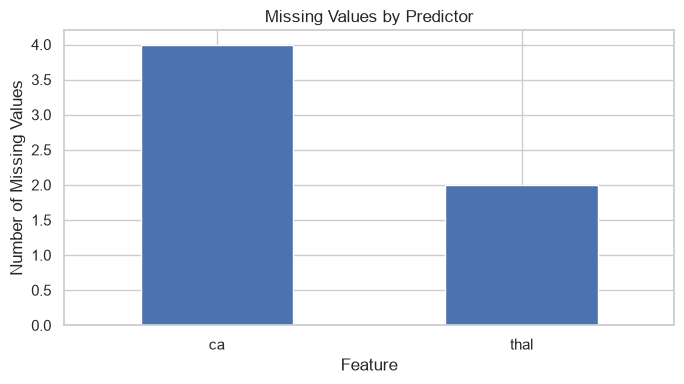


Missing-value analysis: ca


target,0,1
Observed,98.17,99.28
Missing,1.83,0.72



Missing-value analysis: thal


target,0,1
Observed,99.39,99.28
Missing,0.61,0.72


In [40]:
# ============================================================
# 14. Missing-Value Analysis
# ============================================================

missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100)
}).query("Missing_Count > 0").sort_values(
    "Missing_Count", ascending=False
)

display(missing_summary.round(2))

predictor_missing_count = df.drop(
    columns=["num", "target"]
).isna().sum().sum()

predictor_cell_count = (
    df.drop(columns=["num", "target"]).shape[0]
    * df.drop(columns=["num", "target"]).shape[1]
)

print(
    f"Total missing predictor cells: {predictor_missing_count}"
)

print(
    f"Overall missing predictor-cell percentage: "
    f"{predictor_missing_count / predictor_cell_count * 100:.2f}%"
)

missing_summary["Missing_Count"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Missing Values by Predictor")
plt.xlabel("Feature")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Target-stratified missingness rates
missing_features = ["ca", "thal"]

for feature in missing_features:

    print(f"\n{'=' * 60}")
    print(f"Missing-value analysis: {feature}")
    print(f"{'=' * 60}")

    missing_table = pd.crosstab(
        df[feature].isna(),
        df["target"],
        normalize="columns"
    ) * 100

    missing_table.index = ["Observed", "Missing"]

    display(missing_table.round(2))


In [41]:
for feature in missing_features:

    print(f"\n{feature}")

    display(
        pd.crosstab(
            df[feature].isna(),
            df["target"]
        )
    )



ca


target,0,1
ca,,
False,161,138
True,3,1



thal


target,0,1
thal,,
False,163,138
True,1,1


#### 14.1 Missing-Value Relationship Analysis

The dataset contains six missing values across two predictor variables: four missing observations in `ca` and two missing observations in `thal`. This corresponds to 1.32% missingness in `ca`, 0.66% in `thal`, and approximately 0.14% of all predictor cells overall.

For `ca`, three missing observations occur in the target = 0 group and one occurs in the target = 1 group. This corresponds to missingness rates of 1.83% and 0.72%, respectively. The difference is based on only four missing observations and should not be interpreted as evidence of a meaningful relationship between `ca` missingness and the target.

For `thal`, one missing observation occurs in each target group. The corresponding missingness rates are 0.61% for target = 0 and 0.72% for target = 1, indicating very similar observed missingness proportions between the groups.

Overall, the amount of missing data is very small relative to the dataset size. No observations were removed because of missing values. Instead, the missing values will be handled during preprocessing using the planned imputation pipeline. Numerical and categorical preprocessing steps will be fitted only on the training data or within the respective cross-validation folds.

This descriptive analysis does not establish whether the missingness mechanism is MCAR, MAR, or MNAR. It only quantifies the observed missingness pattern and its distribution across the target groups.


### 15. Association Analysis
#### 15.1 Spearman Correlation for Numerical Features


,age,trestbps,chol,thalach,oldpeak,target
age,1.0000,0.2922,0.1913,-0.3916,0.2599,0.2367
trestbps,0.2922,1.0000,0.1358,-0.0404,0.1502,0.1282
chol,0.1913,0.1358,1.0000,-0.0383,0.0344,0.1211
thalach,-0.3916,-0.0404,-0.0383,1.0000,-0.4315,-0.4235
oldpeak,0.2599,0.1502,0.0344,-0.4315,1.0000,0.4134
target,0.2367,0.1282,0.1211,-0.4235,0.4134,1.0000


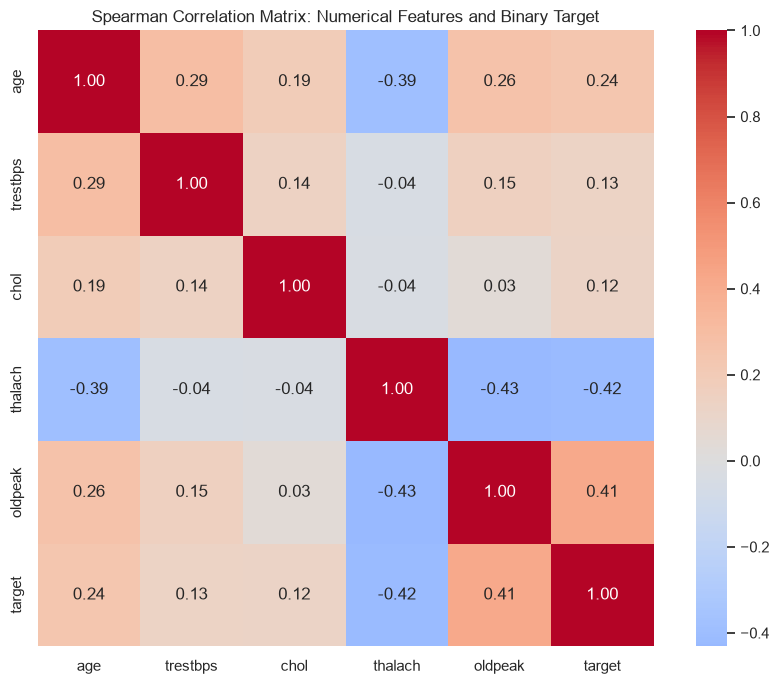

In [42]:
# ============================================================
# 15. Association Analysis
# 15.1 Spearman correlation for numerical features
# ============================================================

from scipy.stats import spearmanr

association_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

spearman_matrix = df[association_features + ["target"]].corr(
    method="spearman"
)

display(spearman_matrix.round(4))

plt.figure(figsize=(9, 7))

sns.heatmap(
    spearman_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Spearman Correlation Matrix: Numerical Features and Binary Target")
plt.tight_layout()
plt.show()


#### 15.2 Spearman Correlation with Target


Spearman rank correlations were used for the five numerical predictors because the EDA identified skewness and potentially unusual observations in several variables. Spearman correlation measures the strength and direction of a monotonic association based on ranks and does not require normally distributed variables.

The observed Spearman correlations with the binary target are:

| Feature | Spearman ρ with target |
|---|---:|
| `age` | 0.2367 |
| `trestbps` | 0.1282 |
| `chol` | 0.1211 |
| `thalach` | -0.4235 |
| `oldpeak` | 0.4134 |

The largest absolute numerical associations with the target are observed for `thalach` and `oldpeak`. These correlations are descriptive rank-based associations and should not be interpreted as feature importance, causal effects, or measures of model performance.

Categorical predictors are not included in this Spearman matrix because their numerical category codes do not generally represent continuous quantitative measurements. Their target associations are instead summarized using contingency-table tests and Cramér's V in the preceding section.


#### 15.3 Interpretation and Limitations of Association Analysis


The association analysis separates numerical and categorical variables according to their measurement structure. Spearman correlation is used for the five numerical predictors, while categorical associations are evaluated using contingency-table tests and Cramér's V.

The Spearman matrix should still be interpreted as an exploratory univariate analysis. A correlation coefficient does not establish causality, clinical significance, or predictive importance. It also does not capture all nonlinear relationships or interactions that may be useful to a machine-learning model.

No predictors are removed solely on the basis of the Spearman correlation analysis or univariate statistical tests. Feature usefulness will instead be evaluated through the subsequent machine-learning experiments using the predefined preprocessing pipeline, stratified cross-validation, and final evaluation on the untouched test set.


### 16. EDA Conclusions

The exploratory data analysis was conducted on the Cleveland subset of the UCI Heart Disease dataset, consisting of 303 observations and 13 predictor variables. The original multiclass target was converted into a binary target, with `target = 0` representing `num = 0` and `target = 1` representing `num = 1, 2, 3, or 4`. The resulting target distribution contained 164 observations in target = 0 and 139 observations in target = 1.

The dataset contained six missing predictor values, consisting of four missing observations in `ca` and two in `thal`. No duplicate observations were identified. The overall amount of missing data was approximately 0.15% of predictor cells, so observations were retained rather than removed. The missingness mechanism cannot be established from this descriptive analysis alone.

The numerical analysis showed distributional differences between the target groups for all five numerical variables. The Mann–Whitney U tests remained statistically significant after Benjamini–Hochberg FDR adjustment across the complete set of 13 final unadjusted p-values. The final rank-biserial correlations were -0.2740 for `age`, -0.1481 for `trestbps`, -0.1403 for `chol`, 0.4906 for `thalach`, and -0.4703 for `oldpeak`.

The categorical analysis identified statistically significant associations after FDR adjustment for `sex`, `cp`, `restecg`, `exang`, `slope`, `ca`, and `thal`. The final bias-corrected Cramér's V values were 0.2639, 0.5108, 0.0000, 0.1632, 0.4216, 0.3807, 0.4806, and 0.5205 for `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, and `thal`, respectively. `fbs` was not statistically significant (FDR-adjusted p = 0.7813). Because of sparse expected frequencies in the `restecg` contingency table, its final p-value was obtained using the Monte-Carlo chi-square procedure with 10,000 simulations and `random_state = 42`; the resulting p-value was 0.0044 and its FDR-adjusted value was 0.0057.

For numerical association analysis, Spearman correlation was used rather than Pearson correlation because it is more appropriate for describing monotonic relationships in the presence of skewness and potentially unusual observations. The strongest absolute Spearman associations with the binary target among numerical variables were observed for `thalach` (ρ = -0.4235) and `oldpeak` (ρ = 0.4134). These associations are descriptive and are not equivalent to predictive feature importance.

Potentially unusual numerical observations were retained because statistical extremeness alone does not establish that an observation is erroneous. No observations were removed solely on the basis of outlier detection, correlation, or univariate statistical significance.

Overall, the EDA identifies distributional and categorical associations within the Cleveland dataset while also documenting missingness, sparse categories, and the measurement limitations of coded categorical variables. These findings inform the preprocessing strategy but do not establish causation, clinical significance, or independent predictive importance. The next stage focuses on implementing a leakage-free preprocessing pipeline and evaluating predictive performance using machine-learning models.


### 17. EDA Findings and Preprocessing Decisions

The EDA findings were used to establish the preprocessing strategy for the machine-learning experiments. The preprocessing decisions are designed to preserve the available observations, handle missing values appropriately, and prevent information leakage.

#### Dataset Split

The machine-learning workflow will use an 80:20 stratified train/test split with `random_state = 42`. Stratification preserves the observed target-class proportions as closely as possible in both partitions. The test set will remain untouched during model development and cross-validation.

#### Missing Values

The variables `ca` and `thal` contain missing observations. Because the number of missing values is very small, observations will not be removed. Both variables are categorical predictors and will therefore be handled using most-frequent imputation.

The imputation parameters will be learned from the training data only. When cross-validation is used, the imputer will be fitted separately within each training fold through the preprocessing pipeline. The test set will not be used to estimate imputation values.

#### Numerical Features

The numerical predictors are:

`age`, `trestbps`, `chol`, `thalach`, and `oldpeak`.

These variables will undergo median imputation followed by standardization using `StandardScaler`. Median imputation provides a robust summary for numerical variables in the presence of skewed observations or extreme values, while standardization places the numerical variables on a comparable scale for algorithms that are sensitive to feature magnitude.

The potentially unusual values identified during EDA will not be removed automatically because there was no established data-quality justification for treating them as erroneous observations.

#### Categorical Features

The categorical predictors are:

`sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, and `thal`.

These variables will undergo most-frequent imputation followed by one-hot encoding using `OneHotEncoder(handle_unknown="ignore")`.

One-hot encoding is preferred because several of these variables are categorical codes rather than continuous numerical measurements. Treating the category codes directly as continuous values could impose artificial numerical relationships between categories.

#### Feature Retention

No predictor will be removed solely because its univariate association or correlation with the target is small. Similarly, statistically significant univariate association will not be interpreted as proof of predictive importance.

All 13 predictors will initially be retained so that their predictive usefulness can be evaluated within the machine-learning experiments.

#### Prevention of Data Leakage

All preprocessing operations will be implemented through a scikit-learn pipeline and, where appropriate, a `ColumnTransformer`. Imputation, scaling, and categorical encoding will therefore be fitted using only the training data.

During cross-validation, preprocessing will be learned separately within each training fold rather than using information from the complete dataset. The final test set will remain untouched until final model evaluation.

#### Reproducibility

The 80:20 stratified train/test split will use `random_state = 42`. Stratified cross-validation will subsequently be applied to the training data for model development and comparison.

The preprocessing design established from the EDA is therefore:

- Numerical features → median imputation → standardization.
- Categorical features → most-frequent imputation → one-hot encoding.
- No row deletion because of the six missing values.
- No automatic removal of statistical outliers.
- No feature elimination based solely on correlation or univariate statistical significance.
- Preprocessing fitted only within the training data and cross-validation folds.
- Final test set retained for final evaluation only.
